# 📊 Notebook 1: Data Preparation for Text-to-SQL Fine-Tuning

Welcome! This is the first notebook in our project.

## What is this project about?
We want to teach a language model (LLM) to **convert natural language questions into SQL queries**.

For example:
- **Input (question):** *"Who were the top 5 merchants by total sales last month?"*
- **Output (SQL):** `SELECT merchant_name, SUM(amount) FROM transactions WHERE ... GROUP BY merchant_name ORDER BY SUM(amount) DESC LIMIT 5`

This capability is called **Text-to-SQL**.

## What does this notebook do?
Before we can train any model, we need to:
1. **Get the data** — load a large Text-to-SQL dataset
2. **Understand the data** — explore what's inside (EDA)
3. **Clean and format the data** — put it in a shape the model can learn from
4. **Split and save** — divide into train/validation sets and save to disk

Think of this notebook as the **kitchen prep** before cooking. The better we prepare ingredients, the better the final dish.

---
⏱️ **Estimated runtime:** ~10-15 minutes on Colab free tier

## Step 1: Install Required Libraries

We need a few Python libraries that aren't pre-installed in Colab:
- `datasets` — HuggingFace's library for loading and processing datasets easily
- `huggingface_hub` — to authenticate with HuggingFace (needed to download the dataset)

The `!` at the start of a cell means we're running a **terminal command**, not Python code.

In [1]:
# Install one at a time to avoid RAM spike from parallel dependency resolution
!pip install -q datasets
!pip install -q huggingface_hub
!pip install -q matplotlib seaborn

## Step 2: Import Libraries

Now we import everything we need into our Python environment.

In [2]:
# 'datasets' is HuggingFace's main library for working with datasets
from datasets import load_dataset, DatasetDict

# pandas is the standard Python library for working with tabular data
import pandas as pd

# matplotlib and seaborn are for creating visualizations/plots
import matplotlib.pyplot as plt
import seaborn as sns

# 're' is Python's built-in library for working with text patterns (regex)
import re

# random lets us randomly sample data — important for getting a fair subset
import random

# os lets us interact with the file system (create folders, check paths, etc.)
import os

# Set a random seed so our results are reproducible
# This means if you run this notebook again, you'll get the same random samples
random.seed(42)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 3: Login to HuggingFace

The dataset we're using (`seeklhy/SynSQL-2.5M`) is hosted on HuggingFace.
To download it, we need to log in with a HuggingFace account.

**How to get your token:**
1. Go to https://huggingface.co/settings/tokens
2. Click "New token" → choose "Read" access
3. Copy the token and paste it when prompted below

In [3]:
# notebook_login() opens an interactive prompt asking for your HuggingFace token
# Your token is like a password that proves you have a HuggingFace account
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Step 4: Load the Dataset

We're using **sql-create-context** — a dataset with ~78k Text-to-SQL pairs.
Each row contains:
- A natural language **question** (e.g., "How many users signed up last week?")
- A database **schema** (the CREATE TABLE statements)
- The correct **SQL query** answer

This dataset is only ~20MB total, so we can load it all at once without streaming.

In [4]:
from datasets import load_dataset

print("Loading sql-create-context dataset...")

# This dataset is only ~20MB total — no streaming needed
# It has the same structure: natural language question + schema + SQL answer
raw_dataset = load_dataset(
    "b-mc2/sql-create-context",
    split="train"
)

print(f"✅ Loaded {len(raw_dataset)} rows")
print(f"   Columns: {raw_dataset.column_names}")

Loading sql-create-context dataset...
✅ Loaded 78577 rows
   Columns: ['answer', 'question', 'context']


## Step 5: Peek at the Data

Before we do anything, let's look at what a single example looks like.
This is always the **first thing** you should do with any dataset.

Since this is a regular dataset (not a stream), we can access rows directly by index.

In [5]:
# Take just the first example from the dataset to inspect it
first_example = raw_dataset[0]  # direct index access, no streaming needed

print("=" * 60)
print("COLUMN NAMES IN THE DATASET:")
print("=" * 60)
for key in first_example.keys():
    print(f"  - {key}")

print()
print("=" * 60)
print("SAMPLE ROW:")
print("=" * 60)
for key, value in first_example.items():
    print(f"\n[{key}]")
    print(str(value)[:300])

COLUMN NAMES IN THE DATASET:
  - answer
  - question
  - context

SAMPLE ROW:

[answer]
SELECT COUNT(*) FROM head WHERE age > 56

[question]
How many heads of the departments are older than 56 ?

[context]
CREATE TABLE head (age INTEGER)


## Step 6: Sample 50,000 Rows

We have ~78k rows available. We'll take 50k to keep things consistent.

We shuffle first so our sample is random rather than just the first 50k rows,
which might be biased toward certain SQL patterns or question types.

In [6]:
# We already have all 78k rows loaded
# Just take the first 50k for consistency with our original plan
import random
random.seed(42)

# Convert to a list of dictionaries for easier processing
print(f"Total available rows: {len(raw_dataset)}")

# Shuffle and take 50k samples
indices = list(range(len(raw_dataset)))
random.shuffle(indices)
selected_indices = indices[:50_000]

collected_samples = [raw_dataset[i] for i in selected_indices]

print(f"✅ Done! Collected {len(collected_samples):,} samples.")

Total available rows: 78577
✅ Done! Collected 50,000 samples.


## Step 7: Convert to Pandas DataFrame

A **DataFrame** is like a spreadsheet in Python — rows and columns.
pandas makes it very easy to explore, filter, and manipulate data.

We'll convert our list of samples into a DataFrame for the EDA section.

In [7]:
# Convert the list of dictionaries into a pandas DataFrame
# Each dictionary becomes a row; dictionary keys become column names
df = pd.DataFrame(collected_samples)

print(f"DataFrame shape: {df.shape}")  # (rows, columns)
print(f"Columns: {df.columns.tolist()}")
print()

# Show the first 3 rows to confirm everything looks right
df.head(3)

DataFrame shape: (50000, 3)
Columns: ['answer', 'question', 'context']



,answer,question,context
0,SELECT type FROM table_1973842_1 WHERE locatio...,"What type is the school located in Macon, Geor...","CREATE TABLE table_1973842_1 (type VARCHAR, lo..."
1,SELECT MIN(rank) FROM table_name_61 WHERE cons...,what is the lowest rank when the constituency ...,"CREATE TABLE table_name_61 (rank INTEGER, cons..."
2,SELECT constructor FROM table_name_10 WHERE dr...,Tell me the constructor for david coulthard,CREATE TABLE table_name_10 (constructor VARCHA...


## Step 8: Exploratory Data Analysis (EDA)

EDA means **exploring the data** to understand what we're working with.
Good EDA helps us:
- Spot problems (missing values, weird outliers)
- Understand the data distribution
- Make better decisions about preprocessing

Think of it like inspecting ingredients before cooking.

The dataset we're using (`b-mc2/sql-create-context`) has three columns:
- `question` — the natural language question
- `context` — the CREATE TABLE schema string
- `answer` — the correct SQL query

In [8]:
print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)

# Check for missing values in each column
# isnull().sum() counts how many NaN (empty) values are in each column
print("\nMissing values per column:")
print(df.isnull().sum())

print()
print("Data types of each column:")
print(df.dtypes)

BASIC STATISTICS

Missing values per column:
answer      0
question    0
context     0
dtype: int64

Data types of each column:
answer      object
question    object
context     object
dtype: object


In [9]:
# We know the exact column names for b-mc2/sql-create-context
# so no need to auto-detect anymore
question_col = 'question'
schema_col   = 'context'   # contains the CREATE TABLE statements
sql_col      = 'answer'    # contains the correct SQL query

print(f"Question column : {question_col}")
print(f"Schema column   : {schema_col}")
print(f"SQL column      : {sql_col}")

Question column : question
Schema column   : context
SQL column      : answer


In [10]:
# Calculate the character length of each question and SQL query
# This tells us how long the inputs and outputs typically are
df['question_len'] = df[question_col].apply(len)
df['sql_len'] = df[sql_col].apply(len)

print("Question length stats (in characters):")
print(df['question_len'].describe())
print()
print("SQL length stats (in characters):")
print(df['sql_len'].describe())

Question length stats (in characters):
count    50000.000000
mean        60.644200
std         23.192625
min         12.000000
25%         43.000000
50%         57.000000
75%         73.000000
max        228.000000
Name: question_len, dtype: float64

SQL length stats (in characters):
count    50000.000000
mean        76.308100
std         24.588905
min         18.000000
25%         62.000000
50%         71.000000
75%         85.000000
max        557.000000
Name: sql_len, dtype: float64


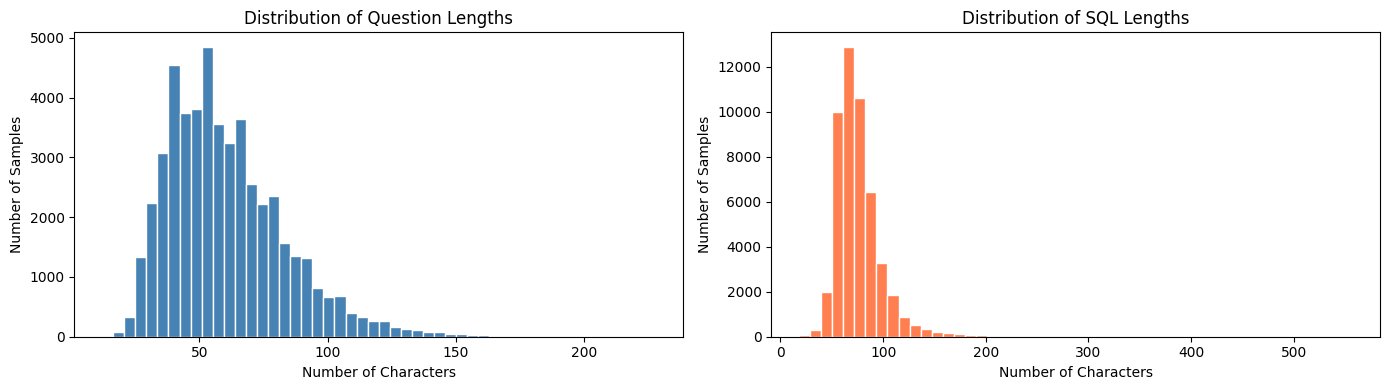

Plot saved as 'length_distribution.png'


In [11]:
# ---- Plot 1: Distribution of question lengths ----
# A histogram shows how many rows fall into each length bucket

fig, axes = plt.subplots(1, 2, figsize=(14, 4))  # 1 row, 2 side-by-side plots

# Left plot: question lengths
axes[0].hist(df['question_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Question Lengths')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Number of Samples')

# Right plot: SQL query lengths
axes[1].hist(df['sql_len'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of SQL Lengths')
axes[1].set_xlabel('Number of Characters')
axes[1].set_ylabel('Number of Samples')

plt.tight_layout()  # prevents plots from overlapping
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')  # save for report
plt.show()
print("Plot saved as 'length_distribution.png'")

In [12]:
# ---- Analyze SQL complexity ----
# SQL queries can be simple (SELECT name FROM users)
# or complex (with JOINs, subqueries, GROUP BY, HAVING, etc.)
# Let's categorize each query by which SQL keywords it uses

def get_sql_complexity(sql):
    """Classify a SQL query into Simple, Medium, or Complex.

    We check for the presence of advanced SQL keywords:
    - Simple: just SELECT ... FROM ... WHERE
    - Medium: has GROUP BY, ORDER BY, or LIMIT
    - Complex: has JOIN, subquery, HAVING, UNION, etc.
    """
    sql_upper = sql.upper()  # convert to uppercase so 'join' and 'JOIN' both match

    # Check for complex keywords first
    complex_keywords = ['JOIN', 'SUBQUERY', 'SELECT.*SELECT', 'HAVING', 'UNION', 'INTERSECT', 'EXCEPT']
    for kw in complex_keywords:
        if re.search(kw, sql_upper):  # re.search checks if pattern exists in string
            return 'Complex'

    # Check for medium keywords
    medium_keywords = ['GROUP BY', 'ORDER BY', 'LIMIT', 'DISTINCT', 'COUNT', 'SUM', 'AVG', 'MAX', 'MIN']
    for kw in medium_keywords:
        if kw in sql_upper:
            return 'Medium'

    # If none of the above, it's simple
    return 'Simple'

# Apply this function to every row in the SQL column
# '.apply()' runs a function on every single value in a column
df['complexity'] = df[sql_col].apply(get_sql_complexity)

# Count how many rows fall into each complexity category
complexity_counts = df['complexity'].value_counts()
print("SQL Complexity Distribution:")
print(complexity_counts)
print()
print("As percentages:")
print((complexity_counts / len(df) * 100).round(1).astype(str) + '%')

SQL Complexity Distribution:
complexity
Simple     31959
Medium     16422
Complex     1619
Name: count, dtype: int64

As percentages:
complexity
Simple     63.9%
Medium     32.8%
Complex     3.2%
Name: count, dtype: object


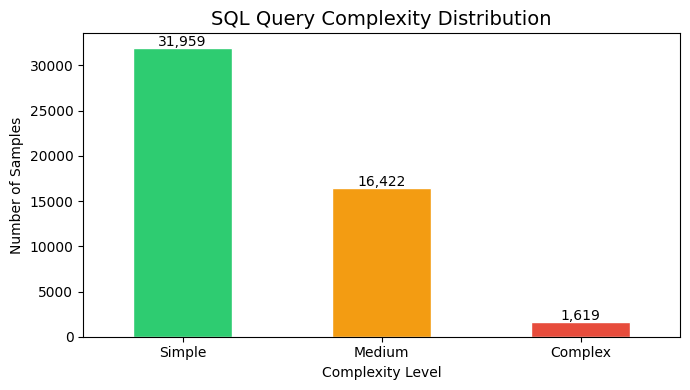

Plot saved as 'complexity_distribution.png'


In [13]:
# ---- Plot 2: SQL Complexity Distribution ----
fig, ax = plt.subplots(figsize=(7, 4))

# A bar chart showing how many queries are Simple / Medium / Complex
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
complexity_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')

ax.set_title('SQL Query Complexity Distribution', fontsize=14)
ax.set_xlabel('Complexity Level')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=0)  # keep x labels horizontal

# Add count labels on top of each bar
for i, (count) in enumerate(complexity_counts):
    ax.text(i, count + 200, f'{count:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('complexity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'complexity_distribution.png'")

## Step 9: Format Data into Prompt Template

Language models learn from **text**. So we need to convert each row
(question + schema + SQL) into a single text string — a "prompt".

The format we use matters a lot. We use a clear, structured template:
```
### Question:
{the natural language question}

### Schema:
{the database table structure}

### SQL:
{the correct SQL query}
```

During training, the model sees the full text including the SQL answer.
During inference (actual use), we give it just the question and schema,
and it learns to complete the SQL part.

In [14]:
def format_prompt(row):
    """Convert one dataset row into a training prompt string.

    This is the exact format the model will learn from.
    Consistent formatting is crucial — the model learns patterns,
    so if the format is inconsistent, the model gets confused.
    """
    # Get the question text, strip removes leading/trailing whitespace
    question = str(row[question_col]).strip()

    # Get the schema — this describes the database table structure
    # If there's no schema column, we use an empty string
    if schema_col and schema_col in row:
        schema = str(row[schema_col]).strip()
    else:
        schema = ""

    # Get the SQL answer
    sql = str(row[sql_col]).strip()

    # Build the full prompt string using an f-string
    # f-strings let you embed variables inside curly braces {}
    prompt = f"""### Question:
{question}

### Schema:
{schema}

### SQL:
{sql}"""

    return prompt


# Apply the formatter to every row in the DataFrame
# This creates a new column called 'text' with the full formatted prompt
df['text'] = df.apply(format_prompt, axis=1)  # axis=1 means apply row by row

print("✅ Prompts formatted! Here's an example:")
print()
print("=" * 60)
print(df['text'].iloc[0])  # show the first formatted prompt
print("=" * 60)

✅ Prompts formatted! Here's an example:

### Question:
What type is the school located in Macon, Georgia?

### Schema:
CREATE TABLE table_1973842_1 (type VARCHAR, location VARCHAR)

### SQL:
SELECT type FROM table_1973842_1 WHERE location = "Macon, Georgia"


## Step 10: Filter Out Bad Samples

Not all rows are useful. We want to remove:
- Rows where any field is empty
- Rows with extremely long prompts (they consume too much GPU memory during training)

We'll keep prompts under **2048 characters** total length.

In [15]:
print(f"Before filtering: {len(df):,} rows")

# Filter 1: Remove rows where any important field is empty/null
df = df.dropna(subset=[question_col, sql_col])  # dropna removes rows with NaN values
print(f"After removing empty rows: {len(df):,} rows")

# Filter 2: Remove rows where the question or SQL is just whitespace
df = df[df[question_col].str.strip() != '']  # str.strip() removes whitespace
df = df[df[sql_col].str.strip() != '']
print(f"After removing whitespace-only rows: {len(df):,} rows")

# Filter 3: Remove rows with extremely long prompts
# Very long sequences slow down training significantly
MAX_PROMPT_LENGTH = 2048  # characters
df['prompt_len'] = df['text'].apply(len)
df = df[df['prompt_len'] <= MAX_PROMPT_LENGTH]
print(f"After removing prompts > {MAX_PROMPT_LENGTH} chars: {len(df):,} rows")

print()
print(f"✅ Filtering complete. Final dataset size: {len(df):,} rows")

Before filtering: 50,000 rows
After removing empty rows: 50,000 rows
After removing whitespace-only rows: 50,000 rows
After removing prompts > 2048 chars: 50,000 rows

✅ Filtering complete. Final dataset size: 50,000 rows


## Step 11: Train / Validation Split

We split our data into two sets:
- **Training set (90%):** The model learns from these examples
- **Validation set (10%):** We use these to check if the model is actually learning,
  without the model ever seeing them during training

This is like a student practicing on past exam papers (training),
then being tested on new questions they've never seen (validation).

In [16]:
# Shuffle the dataframe first so the split is random
# frac=1 means shuffle all rows; random_state=42 makes it reproducible
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Calculate the split index
# int() converts a float to integer (e.g., 45000.0 → 45000)
split_idx = int(len(df) * 0.9)  # 90% for training

# Slice the DataFrame into two parts
# df[:split_idx] means "all rows from the start up to split_idx"
# df[split_idx:] means "all rows from split_idx to the end"
train_df = df[:split_idx]
val_df = df[split_idx:]

print(f"Training samples  : {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")
print(f"Total             : {len(train_df) + len(val_df):,}")

Training samples  : 45,000
Validation samples: 5,000
Total             : 50,000


## Step 12: Convert to HuggingFace Dataset Format and Save

The fine-tuning library (`trl`) works best with HuggingFace `Dataset` objects,
not plain pandas DataFrames. So we convert and save.

We save to Google Drive so the data **persists between Colab sessions**.
(Colab's local storage resets when the session ends!)

In [17]:
# Mount Google Drive so we can save files there permanently
from google.colab import drive
drive.mount('/content/drive')

# Define where we'll save everything in Google Drive
# os.makedirs creates the folder if it doesn't exist yet
SAVE_DIR = '/content/drive/MyDrive/text2sql'
os.makedirs(SAVE_DIR, exist_ok=True)  # exist_ok=True means don't error if folder exists
print(f"✅ Save directory ready: {SAVE_DIR}")

Mounted at /content/drive
✅ Save directory ready: /content/drive/MyDrive/text2sql


In [18]:
from datasets import Dataset

# We only need the 'text' column for training
# (the model learns from the full formatted prompt string)
train_dataset = Dataset.from_pandas(train_df[['text']].reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df[['text']].reset_index(drop=True))

# Combine both into a DatasetDict — a dictionary containing named splits
# This is the standard HuggingFace format
dataset_dict = DatasetDict({
    'train': train_dataset,       # training split
    'validation': val_dataset     # validation split
})

print("Dataset structure:")
print(dataset_dict)

# Save to disk — this creates a folder with the dataset files inside
dataset_save_path = os.path.join(SAVE_DIR, 'dataset')
dataset_dict.save_to_disk(dataset_save_path)

print()
print(f"✅ Dataset saved to: {dataset_save_path}")

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 45000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 5000
    })
})


Saving the dataset (0/1 shards):   0%|          | 0/45000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]


✅ Dataset saved to: /content/drive/MyDrive/text2sql/dataset


In [19]:
# Also save the EDA plots to Google Drive for the report later
import shutil

plots_dir = os.path.join(SAVE_DIR, 'plots')
os.makedirs(plots_dir, exist_ok=True)

# Copy the saved plot files into Google Drive
for plot_file in ['length_distribution.png', 'complexity_distribution.png']:
    if os.path.exists(plot_file):  # check if the file exists before copying
        shutil.copy(plot_file, os.path.join(plots_dir, plot_file))
        print(f"  Copied {plot_file} → Google Drive")

print()
print("✅ All done! Summary:")
print(f"   Training samples  : {len(train_dataset):,}")
print(f"   Validation samples: {len(val_dataset):,}")
print(f"   Dataset saved to  : {dataset_save_path}")
print(f"   Plots saved to    : {plots_dir}")
print()
print("➡️  Next step: Open notebook 02_finetune_qlora.ipynb")

  Copied length_distribution.png → Google Drive
  Copied complexity_distribution.png → Google Drive

✅ All done! Summary:
   Training samples  : 45,000
   Validation samples: 5,000
   Dataset saved to  : /content/drive/MyDrive/text2sql/dataset
   Plots saved to    : /content/drive/MyDrive/text2sql/plots

➡️  Next step: Open notebook 02_finetune_qlora.ipynb
